<a href="https://colab.research.google.com/github/Aastha210/MSE2_Lab_DL/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# topic for Lab and Viva
# Lab 4: Compare RNN vs LSTM vs GRU performance
# Lab 5: Build and train LSTM for text classification, Sequence-to-Sequence.
# Lab 6: Visualize attention heatmaps in Seq2Seq
# Lab 7: Fine-tuning BERT for QA / Sentiment Tasks
# Lab 8:  Build VAE  and visualize latent space.  Train GAN for image synthesis. Implement GCN on citation data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Load IMDb dataset
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 25000
Testing samples: 25000


In [ ]:
maxlen = 200

X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [ ]:
rnn_model = Sequential([
    Embedding(vocab_size, 64, input_length=maxlen),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model = Sequential([
    Embedding(vocab_size, 64, input_length=maxlen),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_model = Sequential([
    Embedding(vocab_size, 64, input_length=maxlen),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2
)

In [ ]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.6169 - loss: 0.6343 - val_accuracy: 0.7294 - val_loss: 0.5330
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.8310 - loss: 0.3828 - val_accuracy: 0.8250 - val_loss: 0.4329
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.8787 - loss: 0.2847 - val_accuracy: 0.7798 - val_loss: 0.5145
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.9736 - loss: 0.0838 - val_accuracy: 0.7816 - val_loss: 0.6090


In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 156ms/step - accuracy: 0.7870 - loss: 0.4425 - val_accuracy: 0.8532 - val_loss: 0.3554
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 159ms/step - accuracy: 0.8939 - loss: 0.2689 - val_accuracy: 0.8514 - val_loss: 0.3573
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 159ms/step - accuracy: 0.9281 - loss: 0.1933 - val_accuracy: 0.8732 - val_loss: 0.3381
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.9524 - loss: 0.1374 - val_accuracy: 0.8696 - val_loss: 0.3487
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - accuracy: 0.9620 - loss: 0.1077 - val_accuracy: 0.8588 - val_loss: 0.3976


In [ ]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 195ms/step - accuracy: 0.7452 - loss: 0.4928 - val_accuracy: 0.8298 - val_loss: 0.3835
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 182ms/step - accuracy: 0.8892 - loss: 0.2762 - val_accuracy: 0.8672 - val_loss: 0.3225
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 199ms/step - accuracy: 0.9286 - loss: 0.1926 - val_accuracy: 0.8730 - val_loss: 0.3212
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.9509 - loss: 0.1355 - val_accuracy: 0.8602 - val_loss: 0.3671
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 189ms/step - accuracy: 0.9680 - loss: 0.0930 - val_accuracy: 0.8556 - val_loss: 0.4525


In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)

print("\nRNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7796 - loss: 0.6193
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8552 - loss: 0.4269
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8414 - loss: 0.4889

RNN Accuracy: 0.7796000242233276
LSTM Accuracy: 0.8551999926567078
GRU Accuracy: 0.8414000272750854


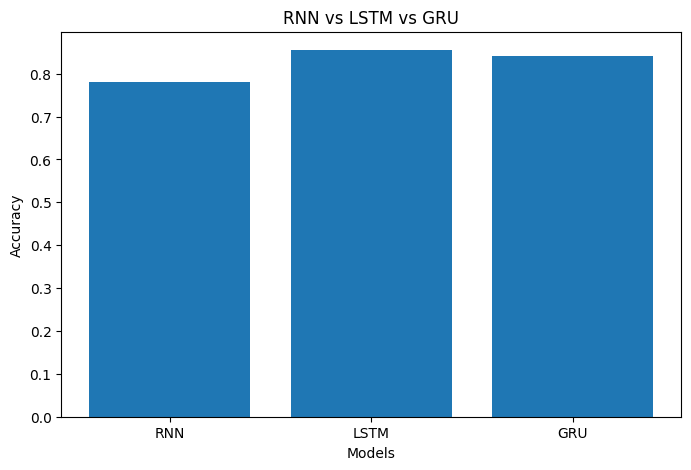

In [ ]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU")
plt.show()